In [30]:
import numpy as np
import matplotlib.pyplot as plt

import read_spectra as rs
import h5py 


In [31]:
# Please, provide the star and magnetization for which you want to have a specific quantity

star = "F3_MH_00" # select from [F3_MH_00, G2_MH_00, G2_MH_m10, G2_MH_p05, K0_MH_00, K4_MH_00, M0_MH_00, M2_MH_00, M4_MH_00]
magnetization = "B200G" # select from [hydro, ssd, B100G, B200G, B300G]
quantity = "spectra" #select from [fundamental_parameters, spectra, limb_darkening, disk_integrated_flux]

In [32]:
wavelengths = rs.get_wavelengths(star)
wavelengths_units = rs.get_units_for_wavelengths(star)
mu = rs.get_mu(star)
if quantity == "fundamental_parameters":
    teff, mh, logg = rs.get_fundamental_parameters(
        star=star,
        magnetization=magnetization
    )
elif quantity == "spectra":
    spectra = rs.get_spectra(
        star=star,
        magnetization=magnetization
    )
    spectra_units = rs.get_units_for_spectra(star)
elif quantity == "limb_darkening":
    limb_darkening = rs.get_limb_darkening(
        star=star,
        magnetization=magnetization
    )  
elif quantity == "disk_integrated_flux":
    flux_spectra = rs.get_disk_integrated_flux(
        star=star,
        magnetization=magnetization
    )
    flux_spectra_units = rs.get_units_for_disk_integrated_flux(star)

Example of plots:
--------

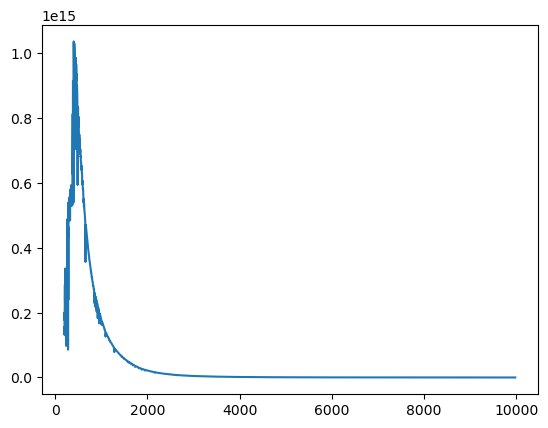

In [33]:

if quantity == "spectra":
    mu_to_plot = 1.0
    ind_mu = np.argmin(abs(mu-mu_to_plot))
    plt.plot(wavelengths, spectra[:, ind_mu])
    plt.show()

elif quantity == "limb_darkening":
    wln_to_plot_in_nm = 1600
    ind_wln = np.argmin(abs(wavelengths-wln_to_plot_in_nm))
    plt.plot(mu, spectra[ind_wln, :])
    plt.show()

elif quantity == "disk_integrated_flux":
    plt.plot(mu, flux_spectra)
    plt.show()

elif quantity == "fundamental_parameters":
    print(f"Teff: {teff} K")
    print(f"[M/H]: {mh}")
    print(f"logg: {logg}")

In [34]:
matrix = np.array([[2,3,4], [5,6,7], [8, 9, 10]])[:, :, np.newaxis]
vector = np.array([2, 3, 4])[np.newaxis, :, np.newaxis]

print(np.einsum('ijt, sjt -> sit', matrix, vector).shape)

(1, 3, 1)


In [35]:
print((np.shape(wavelengths)))
print(np.shape(spectra))

spectra_rev = spectra[:, ::-1]

#wavelengths from nm to m
wavelengths_m = wavelengths * 1e-9


#convert from /Hz to /Angstrom
spectra_rev_per_Hz = spectra_rev  * 10**10 * wavelengths_m[:, np.newaxis]**2 / 3e8 **2
#print(wavelengths[:,np.newaxis])
data = np.column_stack((wavelengths, spectra_rev_per_Hz))
print(data[150:])

#generate a .txt file with the header: wavelength i10 i09 i08 i07 i06 i05 i04 i03 i02 i01 and append all wavelength and spectra data
header = "wavelength i10 i09 i08 i07 i06 i05 i04 i03 i02 i01"



np.savetxt(
    f"../{star}_{magnetization}_intensities_nadiia.txt",
    data,
    header=header,
    fmt="%.8f"
)

(978,)
(978, 10)
[[4.05000060e+02 1.83455839e-05 1.73346812e-05 ... 1.08204041e-05
  9.10686500e-06 6.64563544e-06]
 [4.07000060e+02 1.79567949e-05 1.70012679e-05 ... 1.07134874e-05
  9.03733688e-06 6.62775651e-06]
 [4.09000060e+02 1.63111875e-05 1.55738903e-05 ... 1.04322150e-05
  8.96788737e-06 6.79044253e-06]
 ...
 [9.90000139e+03 4.93001347e-07 4.91243517e-07 ... 4.75865754e-07
  4.71501470e-07 4.64505775e-07]
 [9.94000139e+03 4.89088311e-07 4.87349199e-07 ... 4.72135278e-07
  4.67818460e-07 4.60891200e-07]
 [9.98000140e+03 4.85315494e-07 4.83594664e-07 ... 4.68539969e-07
  4.64268080e-07 4.57408196e-07]]
